# Programming Exercise 3: Logistic Regression



## Introduction

In this exercise, you will implement logistic regression and apply it to two different datasets.

All the information you need for solving this assignment is in this notebook, and all the code you will be implementing will take place within this notebook.

Before we begin with the exercises, we need to import all libraries required for this programming exercise. Throughout the course, we will be using [`numpy`](http://www.numpy.org/) for all arrays and matrix operations, and [`matplotlib`](https://matplotlib.org/) for plotting.

### Section 1 Logistic Regression

In this part of the exercise, you will build a logistic regression model to predict whether a student gets admitted into a university. Suppose that you are the administrator of a university department and
you want to determine each applicant’s chance of admission based on their results on two exams. You have historical data from previous applicants that you can use as a training set for logistic regression. For each training example, you have the applicant’s scores on two exams and the admissions
decision. Your task is to build a classification model that estimates an applicant’s probability of admission based the scores from those two exams.

The following cell will load the data and corresponding labels:

In [226]:
import pandas as pd
import numpy as np


In [227]:
  students = pd.read_csv("ex2data1.txt", names=["First_Exam", "Second_Exam", "Admission_Status"])
  # type casting from pandas series and pandas dataframe to numpy array
  X = np.array(students[["First_Exam", "Second_Exam"]])
  y = np.array(students["Admission_Status"])
  # size of dataset
  number_of_samples = y.size
  # size of X matrix, m= rows, n= features
  m,n = X.shape
  print('size of samples: {}'.format(number_of_samples))

size of samples: 100


In [228]:
students.head()

,First_Exam,Second_Exam,Admission_Status
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


### 1.1 Visualizing the data

Before starting to implement any learning algorithm, it is always good to visualize the data if possible.
please visualize the first dataset using the package `matplotlib`.

In [229]:
import matplotlib.pyplot as plt

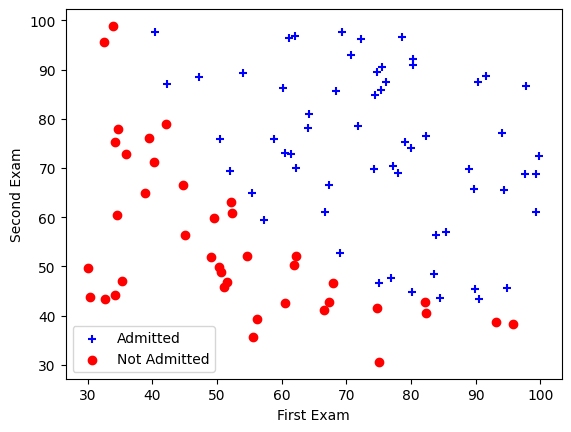

In [230]:
# Plot admitted and not admitted
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='+', label='Admitted')
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', marker='o', label='Not Admitted')

# Set labels and legend
plt.xlabel('First Exam')
plt.ylabel('Second Exam')
plt.legend()
plt.show()


### 1.2 Implementation

#### 1.2.1 Warmup exercise: sigmoid function

Before you start with the actual cost function, recall that the logistic regression hypothesis is defined as:

$$ h_\theta(x) = g(\theta^T x)$$

where function $g$ is the sigmoid function. The sigmoid function is defined as:

$$g(z) = \frac{1}{1+e^{-z}}$$.

Your first step is to implement this function `sigmoid` so it can be
called by the rest of your program. When you are finished, try testing a few
values by calling `sigmoid(x)` in a new cell. For large positive values of `x`, the sigmoid should be close to 1, while for large negative values, the sigmoid should be close to 0. Evaluating `sigmoid(0)` should give you exactly 0.5. Your code should also work with vectors and matrices. **For a matrix, your function should perform the sigmoid function on every element.**


In [231]:
def sigmoid(z):
  g = 1 / (1 + np.exp(-z))
  return g

In [232]:
# test sigmoid function
z = 0
g = sigmoid(z)

print("Actual value of sigmoid(0) should be 0.5")
print("Computed value of sigmoid(0) is {sigmoid}".format(sigmoid= g))

Actual value of sigmoid(0) should be 0.5
Computed value of sigmoid(0) is 0.5


#### 1.2.2 Cost function and gradient

Now you will implement the cost function and gradient for logistic regression. Before proceeding we add the intercept term to X.


In [233]:
# add intercept term to martix X
X = np.concatenate([np.ones((len(X), 1)), X], axis= 1)
### make  theta_0 as the bias term

Note that the parameter $\theta_0$ represents the bias term in the model's weights.
Now, complete the code for the function `cost_function` to return the cost value and define `gradient_descent` to reteun gradient. Recall that the cost function in logistic regression is

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

and the gradient of the cost is a vector of the same length as $\theta$ where the $j^{th}$
element (for $j = 0, 1, \cdots , n$) is defined as follows:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

Note that while this gradient looks identical to the linear regression gradient, the formula is actually different because linear and logistic regression have different definitions of $h_\theta(x)$.

In [234]:
def cost_function(theta, X, y):
    m = len(y)
    cost = 0
    # small value to avoid log(0)
    epsilon = 1e-5

    for i in range(m):
        h = np.clip(sigmoid(np.dot(X[i], theta)), epsilon, 1 - epsilon)
        # cost for positive and negative classes and then sum them
        term1 = -y[i] * np.log(h)
        term2 = (1 - y[i]) * np.log(1 - h)
        cost += term1 - term2
    # average cost
    J = cost / m
    return J


In [235]:
def gradient_descent(theta, X, y):
    m = len(y)
    n = len(theta)
    # initialize gradient vector with zeros
    grad = np.zeros(n)

    for j in range(n):
        for i in range(m):
            # prediction for sample i
            h = sigmoid(np.dot(X[i], theta))
            # gradient for feature j
            grad[j] += (h - y[i]) * X[i][j]

    # average gradient
    grad /= m
    return grad


In [ ]:
### check the gradient and with theta=np.zeros(n+1)

In [236]:
# initialize theta with zeros and compute gradient, cost for it
initial_theta = np.zeros(n+1)
grad = gradient_descent(initial_theta, X, y)
cost = cost_function(initial_theta,X,y)
print("Shape of cost value is: {}".format(cost))
print("Shape of grad is: {}".format(grad.shape))

Shape of cost value is: 0.6931471805599458
Shape of grad is: (3,)


### calculate the optimal theta using stochastic gradient deacent




In [237]:
def train_using_sgd(theta, X, y, learning_rate=0.0074, epochs=500):

    m = len(y)
    best_cost = np.inf
    best_theta = theta.copy()

    for epoch in range(epochs):
        # shuffle training examples Indexes and run through them
        indices = np.arange(m)
        np.random.shuffle(indices)

        for i in indices:
            # compute prediction and error
            hi = sigmoid(np.dot(X[i], theta))
            error = hi - y[i]
            gradient = error * X[i]
            # compute gradient and update currrent theta
            theta -= learning_rate * gradient

        cost = cost_function(theta, X, y)

        # update best theta only if cost improved
        if cost < best_cost:
            best_cost = cost
            best_theta = theta.copy()

    return best_theta


# initialize theta and train using SGD
initial_theta = np.zeros(X.shape[1])
theta_optimized = train_using_sgd(initial_theta, X, y)

In [238]:

print("Optimized theta is: {}".format(theta_optimized))
optimaize_cost = cost_function(theta_optimized,X,y)

print("Optimized Cost value is: {:.4f}".format(optimaize_cost))

Optimized theta is: [-25.28562816   0.23144133   0.16971901]
Optimized Cost value is: 0.2407


### Plot the decision boundary obtained from the logistic regression model trained using gradient descent

---



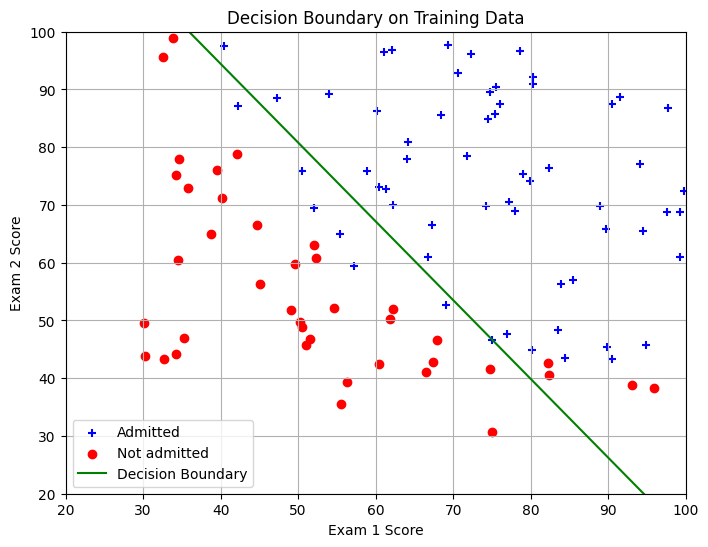

In [239]:


pos = y == 1
neg = y == 0

plt.figure(figsize=(8,6))

# plot positive and negative examples
plt.scatter(X[pos, 1], X[pos, 2], c='b', marker='+', label='Admitted')
plt.scatter(X[neg, 1], X[neg, 2], c='r', marker='o', label='Not admitted')

# plot decision boundary
x_values = np.array([np.min(X[:, 1]), np.max(X[:, 1])])
y_values = -(theta_optimized[0] + theta_optimized[1]*x_values) / theta_optimized[2]
plt.plot(x_values, y_values, label='Decision Boundary', color='green')

# set labels, title and grid
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.legend()
plt.grid(True)
plt.title("Decision Boundary on Training Data")
plt.xlim(20, 100)
plt.ylim(20, 100)
plt.show()


#### 1.2.4 Evaluating logistic regression

After learning the parameters, you can use the model to predict whether a particular student will be admitted. For a student with an Exam 1 score of 53 and an Exam 2 score of 94, print the admission
probability.

In [240]:
def predict(theta, X):
  rows= X.shape[0]
  predicted = np.zeros(rows)
  for i in range (rows):
    # compute probability
    predicted[i] = sigmoid(np.dot(X[i], theta))
    # aplly calssification
    if predicted[i] >= 0.5:
      predicted[i] = 1
    else:
      predicted[i] = 0

  return predicted

In [241]:
def accuracy(y_pred, y):
   # count errors
   diff = 0
   m = len(y)
   for i in range(m):
        current_diff = abs(y_pred[i] - y[i])
        if current_diff > 0:
            diff += 1

   # compute accuracy as requested
   accuracy = 1 - diff / m
   return accuracy

After you have completed the code in `predict`, we proceed to report the training accuracy of your classifier by computing the percentage of examples it got correct.

In [242]:
# Predict probability for a student with score 45 on exam 1
# and score 85 on exam 2
student_scores = np.array([1, 53, 94])
prob = sigmoid(np.dot(student_scores, theta_optimized))
print("Admission probability for a student with scores 53 and 94: {:.4f}".format(prob))
accuracy = accuracy(predict(theta_optimized, X), y)
print("Train Accuracy: {:.1f}".format(accuracy * 100))


Admission probability for a student with scores 53 and 94: 0.9495
Train Accuracy: 89.0


plot the AUC and the ROC curve on your model

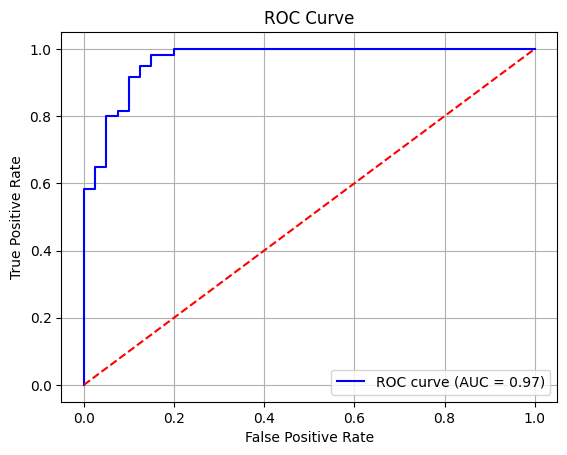

In [244]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# compute predicted scores
y_scores = sigmoid(X @ theta_optimized)

fpr, tpr, thresholds = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

# plot ROC curve
plt.plot(fpr, tpr, color='blue', label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()




```
# This is formatted as code
```

## Section 2 Regularized logistic regression

In this part of the exercise, you will implement regularized logistic regression to predict whether microchips from a fabrication plant passes quality assurance (QA). During QA, each microchip goes through various tests to ensure it is functioning correctly.
Suppose you are the product manager of the factory and you have the test results for some microchips on two different tests. From these two tests, you would like to determine whether the microchips should be accepted or rejected. To help you make the decision, you have a dataset of test results on past microchips, from which you can build a logistic regression model.

First, we load the data from a CSV file:

In [245]:
microchips= pd.read_csv("ex2data2.txt", names=["First_Test", "Second_Test", "Status"])
# type casting from pandas series and pandas dataframe to numpy array
X = np.array(microchips[["First_Test", "Second_Test"]])
y = np.array(microchips["Status"])
# size of dataset
number_of_samples = y.size
# size of X matrix, m= rows, n= features
m,n = X.shape
print('size of samples: {}'.format(number_of_samples))

size of samples: 118


### 2.1 Visualize the data

Similar to the previous parts of this exercise, where the axes are the two test scores, and the positive (y = 1, accepted) and negative (y = 0, rejected) examples are shown with
different markers.

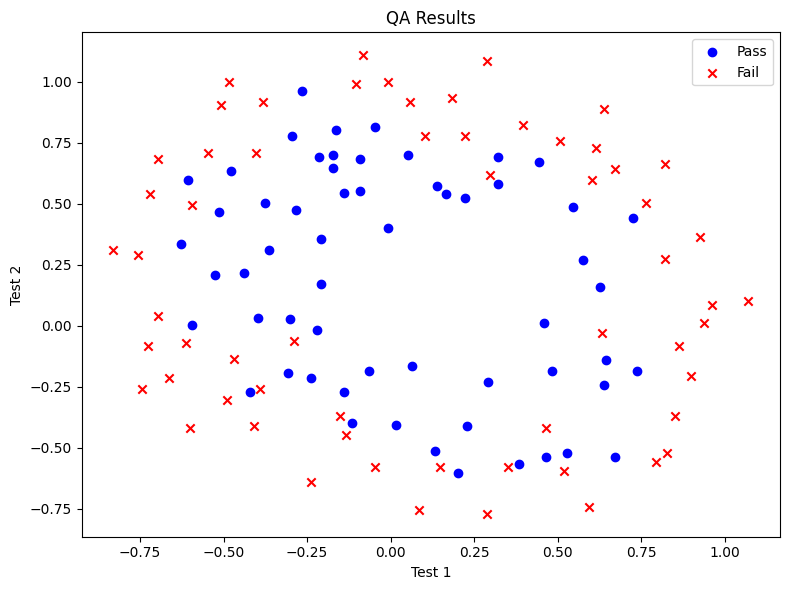

In [246]:
import matplotlib.pyplot as plt

# split data by status
data_pos = microchips[microchips["Status"] == 1]
data_neg = microchips[microchips["Status"] == 0]

plt.figure(figsize=(8,6))
# plot passing adn failing microchips
plt.scatter(data_pos["First_Test"], data_pos["Second_Test"], c='b', marker='o', label='Pass')
plt.scatter(data_neg["First_Test"], data_neg["Second_Test"], c='r', marker='x', label='Fail')

plt.xlabel("Test 1")
plt.ylabel("Test 2")
plt.title("QA Results")
plt.legend()
plt.tight_layout()
plt.show()


The above figure shows that our dataset cannot be separated into positive and negative examples by a straight-line through the plot. Therefore, a straight-forward application of logistic regression will not perform well on this dataset since logistic regression will only be able to find a linear decision boundary.

### 2.2 Feature mapping

One way to fit the data better is to create more features from each data point. In the function `map_feature`, we will map the features into all polynomial terms of $x_1$ and $x_2$ up to the sixth power.

$$ \text{map_feature}(x) = \begin{bmatrix} 1 & x_1 & x_2 & x_1^2 & x_1 x_2 & x_2^2 & x_1^3 & \dots & x_1 x_2^5 & x_2^6 \end{bmatrix}^T $$

As a result of this mapping, our vector of two features (the scores on two QA tests) has been transformed into a 28-dimensional vector. A logistic regression classifier trained on this higher-dimension feature vector will have a more complex decision boundary and will appear nonlinear when drawn in our 2-dimensional plot.
While the feature mapping allows us to build a more expressive classifier, it also more susceptible to overfitting. In the next parts of the exercise, you will implement regularized logistic regression to fit the data and also see for yourself how regularization can help combat the overfitting problem.


In [ ]:
### make the map feature function

In [247]:
def map_feature(X1, X2, degree=6):
    m = len(X1)
    array_like = np.zeros((m, 28))
    index = 0

    # loop over total degree
    for i in range(degree + 1):
      # loop over current split between X1 and X2 powers
        for j in range(i + 1):
          # loop over all samples
            for k in range(m):
                array_like[k][index] = (X1[k] ** (i - j)) * (X2[k] ** j)

            # move to next column in output array
            index += 1

    return array_like




In [248]:
X = map_feature(X[:,0], X[:,1])

### 2.3 Cost function and gradient
Note that the parameter $\theta_0$ represents the bias term in the model's weights.
Now you will implement code to compute the cost function and gradient for regularized logistic regression. Complete the code for the function `cost_function_gradient_descent_regularized` below to return the cost and gradient.

Recall that the regularized cost function in logistic regression is

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^m \left[ -y^{(i)}\log \left( h_\theta \left(x^{(i)} \right) \right) - \left( 1 - y^{(i)} \right) \log \left( 1 - h_\theta \left( x^{(i)} \right) \right) \right] + \frac{\lambda}{2m} \sum_{j=1}^n \theta_j^2 $$

Note that you should not regularize the parameters $\theta_0$. The gradient of the cost function is a vector where the $j^{th}$ element is defined as follows:

$$ \frac{\partial J(\theta)}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left(x^{(i)}\right) - y^{(i)} \right) x_j^{(i)} \qquad \text{for } j =0 $$

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \left( \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left(x^{(i)}\right) - y^{(i)} \right) x_j^{(i)} \right) + \frac{\lambda}{m}\theta_j \qquad \text{for } j \ge 1 $$

In [249]:
def cost_function_gradient_descent_regularized(theta, X, y, lambda_):
    m = y.size
    n = len(theta)
    J = 0
    grad = np.zeros(n)
    # to avoid log(0)
    epsilon = 1e-5

    # compute unregularized cost
    for i in range(m):
        h = np.clip(sigmoid(np.dot(X[i], theta)), epsilon, 1 - epsilon)
        term1 = -y[i] * np.log(h)
        term2 = (1 - y[i]) * np.log(1 - h)
        J += term1 - term2

    # compute sum of squares for regularization (skip theta[0])
    sum3=0
    for j in range (1, n):
      sum3 += (theta[j]) ** 2

    term3 = (lambda_ / (2 * m)) * sum3
    J = J / m
    J += term3

    # compute gradient for theta[0]
    for i in range(m):
        h = sigmoid(np.dot(X[i], theta))
        grad[0] += (h - y[i]) * X[i][0]

    # compute gradient for the rest
    for j in range(1, n):
        for i in range(m):
            h = sigmoid(np.dot(X[i], theta))
            grad[j] += (h - y[i]) * X[i][j]

    grad = grad / m


    return J, grad


#### 2.3.1 Learning parameters using momentum

Similar to the previous parts, you will optimize the Regularized logistic regression using the momentum algorithm optimize the model with $\lambda = 1$, $\lambda = 0$

In [250]:
def train_using_momentum(theta, X, y, learning_rate,beta,lmbda, epochs=100):
    velocity = np.zeros_like(theta)
    for epoch in range(epochs):

       # compute cost and gradient with regularization and update velocity
        cost, grad = cost_function_gradient_descent_regularized(theta, X, y,
                                                                lmbda)
        velocity = beta * velocity + learning_rate * grad
        # update the theta using the velocity
        theta = theta - velocity

    return theta


# initialize theta and train the model
initial_theta = np.zeros(X.shape[1])
theta_optimized = train_using_momentum(
    np.zeros(X.shape[1]),
    X,
    y,
    0.1,
    0.9,
    1
)



In [251]:
# Compute accuracy on our training set
model_predicted = predict(theta_optimized, X)

print("Train Accuracy: {:.1f}".format((np.mean(model_predicted == y) * 100)))
print("Expected accuracy (with lambda = 1): 83.1 % (approx)\n")

Train Accuracy: 83.1
Expected accuracy (with lambda = 1): 83.1 % (approx)



### plot the decision boundery for $\lambda =1$




In [252]:
def plot_decision_boundary(theta, X, y):
    pos = y == 1
    neg = y == 0


    plt.figure(figsize=(8,6))

    # plot positive and negative examples
    plt.scatter(X[pos][:, 1], X[pos][:, 2], c='b', marker='+', label='Accepted')
    plt.scatter(X[neg][:, 1], X[neg][:, 2], c='r', marker='o', label='Rejected')

    # create grid to evaluate model
    u = np.linspace(-1, 1.5, 100)
    v = np.linspace(-1, 1.5, 100)
    z = np.zeros((len(u), len(v)))
    for i in range(len(u)):
        for j in range(len(v)):
            z[i][j] = (map_feature(np.array([u[i]]), np.array([v[j]])) @ theta)[0]

    # calculate z transpose
    z = z.T

    # plot decision boundary
    plt.contour(u, v, z, levels=[0], linewidths=2, colors='g')
    plt.xlabel('Test 1')
    plt.ylabel('Test 2')
    plt.legend()
    plt.title("Decision Boundary")
    plt.grid(True)
    plt.show()



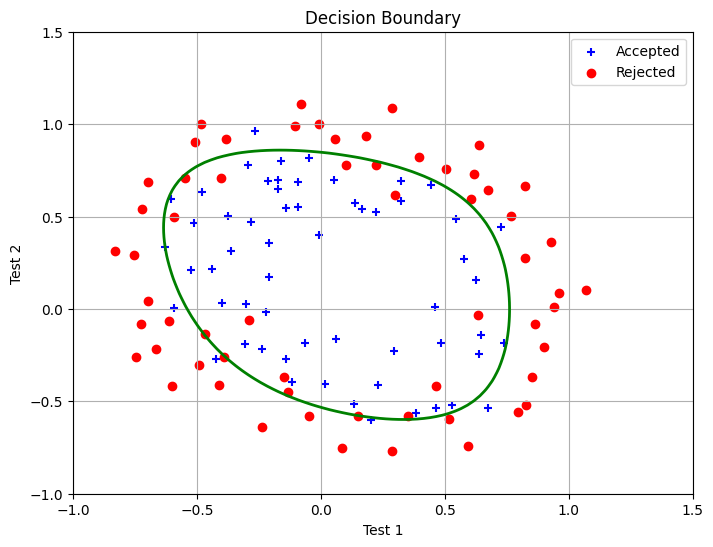

In [253]:
# for lambda = 1
theta_1 = train_using_momentum(np.zeros(X.shape[1]), X, y, 0.1, 0.9, 1, 300)

plot_decision_boundary(theta_1, X[:, :3], y)



### plot the decision boundery for $\lambda=0$




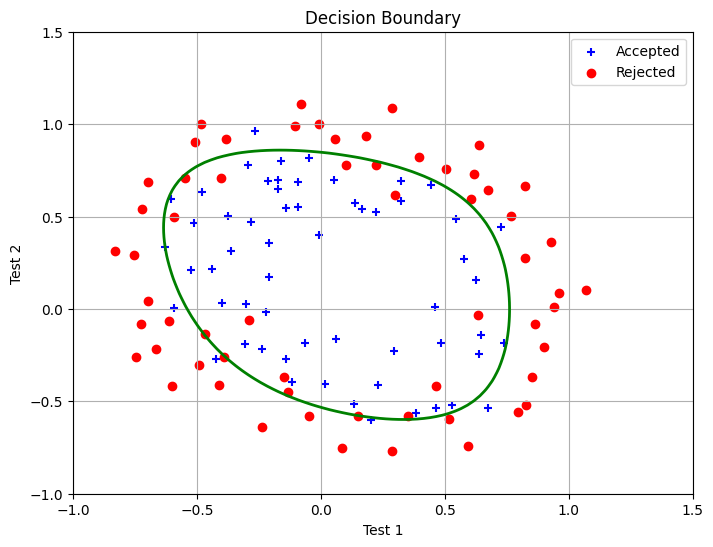

In [254]:
# for lambda = 0
theta_0 = train_using_momentum(np.zeros(X.shape[1]), X, y, 0.1, 0.9, 0, 300)

plot_decision_boundary(theta_0, X[:, :3], y)
